## Are codes actually getting more efficient as we progress through a network?

In [4]:
from models import NoisyMLP
import torch
torch.set_float32_matmul_precision("high")
from torch.utils.data import DataLoader
import wandb
import lightning as pl
from lightning import Trainer
from lightning.pytorch.callbacks import EarlyStopping, Callback
from lightning.pytorch.loggers import WandbLogger
from accelerate.test_utils.testing import get_backend

# plotting
import matplotlib.pyplot as plt

# MNIST dataset, lightning datamodule
from torchvision import datasets, transforms
from lightning.pytorch import LightningDataModule

class MNISTDataModule(LightningDataModule):
    def __init__(self, batch_size=32):
        super().__init__()
        self.batch_size = batch_size
        self.transform = transforms.Compose([transforms.ToTensor()])
        self.train_dataset = datasets.MNIST(root='.', train=True, download=True, transform=self.transform)
        self.val_dataset = datasets.MNIST(root='.', train=False, download=True, transform=self.transform)
    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size)
    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

wandb_logger = WandbLogger(project="efficient-coding")
device, n_devices, mem = get_backend()

In [2]:
# need softmax and entropy
import scipy


# Callback for logging activations
class ActivationLogger(Callback):
    def __init__(self, log_every_n_epochs=1):
        """
        Args:
            log_every_n_epochs: Only log activations every N validation epochs 
                                to avoid huge logs.
        """
        super().__init__()
        self.log_every_n_epochs = log_every_n_epochs
        self.handles = []      # Store hook handles so we can remove them later
        self.activations = {}  # Will hold the latest outputs from each hooked layer

    def on_fit_start(self, trainer, pl_module):
        # Register hooks on each layer of interest (e.g., nn.ReLU activations) in pl_module.layers
        idx = 0
        for layer in pl_module.layers:
            if isinstance(layer, torch.nn.ReLU):
                handle = layer.register_forward_hook(self._make_hook(f"linear_{idx}"))
                self.handles.append(handle)
                idx += 1

    def _make_hook(self, layer_name):
        """Create a hook function that captures the forward output."""
        def hook(module, input, output):
            # Store the output in a dict, detach so we don't keep gradients
            self.activations[layer_name] = output.detach()
        return hook

    def on_validation_epoch_end(self, trainer, pl_module):
        """Log activations to wandb after each validation epoch."""
        if trainer.current_epoch % self.log_every_n_epochs != 0:
            return  # Skip logging if it's not the right epoch

        # Grab one batch from the validation dataloader
        sample_batch = next(iter(trainer.val_dataloaders))
        x, _ = sample_batch

        # Move input to the correct device
        x = x.to(pl_module.device)

        # Optionally set the model to eval mode so dropout is inactive
        pl_module.eval()
        with torch.no_grad():
            _ = pl_module(x)  # Forward pass populates self.activations via the hooks

        # Now log the stored activations to wandb
        for layer_name, act in self.activations.items():
            # Flatten for histogram logging
            act_data = act.view(-1).cpu().numpy()
            trainer.logger.experiment.log({
                f"activations/{layer_name}": wandb.Histogram(act_data),
                f"activations/{layer_name}_mean": act_data.mean(),
                f"activations/{layer_name}_std": act_data.std(),
                f"activations/{layer_name}_entropy": scipy.stats.entropy(scipy.special.softmax(act_data)),
                "global_step": trainer.global_step,
                "epoch": trainer.current_epoch
            })

        # Clear the activations dict
        self.activations.clear()

        # Return model to train mode if desired
        pl_module.train()

    def on_fit_end(self, trainer, pl_module):
        # Remove the hooks
        for h in self.handles:
            h.remove()
        self.handles.clear()

In [ ]:
model = NoisyMLP()

mnist = MNISTDataModule(batch_size=32)
trainer = Trainer(max_epochs=100,
                  logger=wandb_logger, 
                  callbacks=[EarlyStopping(monitor="val/loss"), 
                             ActivationLogger(log_every_n_epochs=1)])

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


wandb: Currently logged in as: jhrudoler (jhrudoler-penn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
/home/jrudoler/.cache/pypoetry/virtualenvs/efficient-coding-7IazfzCm-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/jrudoler/.cache/pypoetry/virtualenvs/efficient ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [4]:
# def get_activation_hook(name, activation_dict):
#     """Returns a function that will store the output of a layer in a dictionary."""
#     def hook(model, input, output):
#         activation_dict[name] = output.detach()
#     return hook


# model.eval()

# # Dictionary to store the activations
# activations = {}

# # Register forward hooks on the layers you care about
# # For instance, let's hook after each Linear
# for idx, layer in enumerate(model.layers):
#     if isinstance(layer, torch.nn.ReLU):
#         layer.register_forward_hook(get_activation_hook(f"layer_{idx}", activations))

In [5]:
trainer.fit(model, datamodule=mnist)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name   | Type       | Params | Mode 
----------------------------------------------
0 | layers | Sequential | 151 K  | train
----------------------------------------------
151 K     Trainable params
0         Non-trainable params
151 K     Total params
0.605     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/jrudoler/.cache/pypoetry/virtualenvs/efficient-coding-7IazfzCm-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/home/jrudoler/.cache/pypoetry/virtualenvs/efficient-coding-7IazfzCm-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [2]:
api = wandb.Api()
run = api.run("jhrudoler-penn/efficient-coding/i2x59z35")
history = run.history()
activation_data = history[['epoch', 'activations/linear_0_mean', 'activations/linear_0_std', 'activations/linear_0_entropy']]
valid_data = activation_data.dropna()

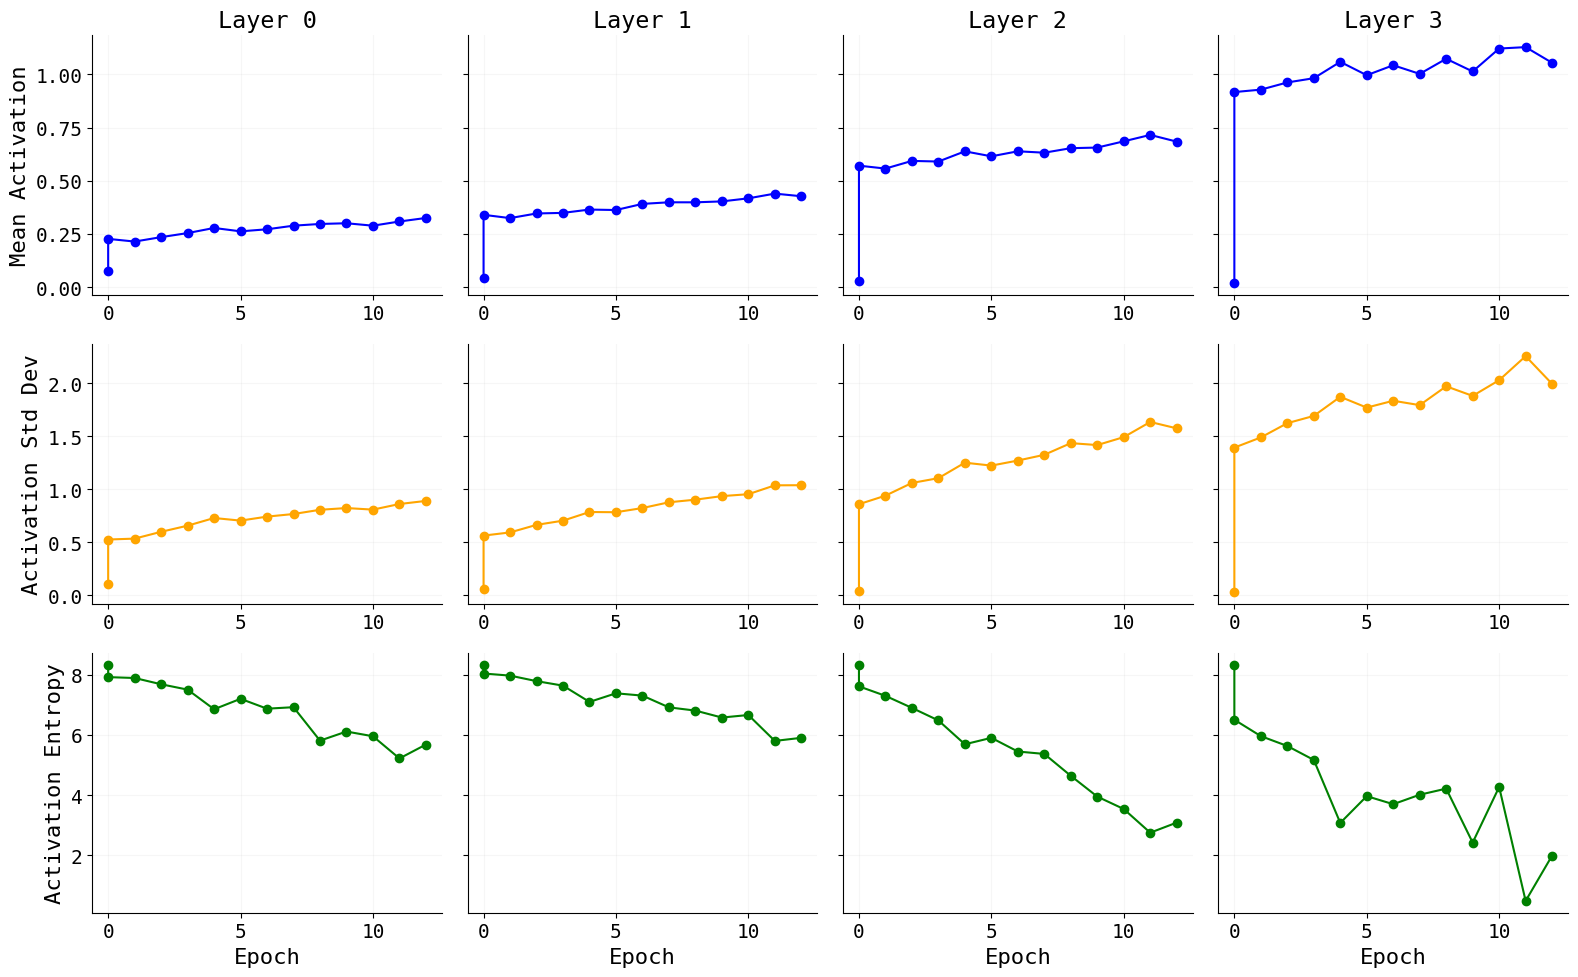

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Set your plotting style
plt.style.use("~/clean-figs.mplstyle")

# First, let's determine how many layers we have by looking at column names
layer_indices = set()
for col in history.columns:
    if col.startswith('activations/linear_') and col.endswith('_mean'):
        # Extract the layer index from the column name
        layer_idx = int(col.split('_')[1])
        layer_indices.add(layer_idx)

# Sort the indices
layer_indices = sorted(layer_indices)
num_layers = len(layer_indices)

# Create a figure with a 3xN grid (3 metrics, N layers)
fig, axes = plt.subplots(3, num_layers, figsize=(4*num_layers, 10), sharey='row')

# Metrics to plot
metrics = ['mean', 'std', 'entropy']
metric_colors = ['blue', 'orange', 'green']
metric_titles = ['Mean Activation', 'Activation Std Dev', 'Activation Entropy']

# Plot each layer's metrics in columns
for col_idx, layer_idx in enumerate(layer_indices):
    layer_name = f'linear_{layer_idx}'
    
    # For each metric (row)
    for row_idx, (metric, color, title) in enumerate(zip(metrics, metric_colors, metric_titles)):
        col_name = f'activations/{layer_name}_{metric}'
        
        # Get data for this layer and metric, dropping NaNs
        valid_layer_data = history[['epoch', col_name]].dropna()
        
        # Get the axis for this subplot
        ax = axes[row_idx, col_idx]
        
        # Plot the data
        ax.plot(valid_layer_data['epoch'], valid_layer_data[col_name], 'o-', color=color)
        
        # Set titles and labels
        if row_idx == 0:
            ax.set_title(f'Layer {layer_idx}')
        if col_idx == 0:
            ax.set_ylabel(title)
        if row_idx == 2:
            ax.set_xlabel('Epoch')
        
        ax.grid(True)

plt.tight_layout()
plt.show()